In [1]:
"""Proposal-faithful RQ6 artifact generator.

This script reads frozen Phase 3 operational outputs and generates only the
proposal-facing RQ6 artifacts in a separate reporting layer.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid")


# Update this path in Kaggle before running.
PHASE3_INPUT_ROOT = Path("/kaggle/input/datasets/ashwinwalunj/ashwin-thesis-outputs-phase3/thesis_outputs")
OUTPUT_ROOT = Path("/kaggle/working/thesis_outputs")

RQ = "rq6"
RQ_OUTPUT_ROOT = OUTPUT_ROOT / "results_proposal" / RQ
FIGURES_ROOT = RQ_OUTPUT_ROOT / "figures"
TABLES_ROOT = RQ_OUTPUT_ROOT / "tables"
for folder in [FIGURES_ROOT, TABLES_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)


def save_table(df, name):
    df.to_csv(TABLES_ROOT / f"{name}.csv", index=False)


def save_figure(fig, name):
    fig.savefig(FIGURES_ROOT / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES_ROOT / f"{name}.pdf", bbox_inches="tight")
    plt.show()


PHASE3_ARTIFACTS = PHASE3_INPUT_ROOT / "artifacts" / "phase03_ranking_explainability"
required_files = [
    PHASE3_ARTIFACTS / "budget_performance_raw.csv",
    PHASE3_ARTIFACTS / "roi_analysis_raw.csv",
    PHASE3_ARTIFACTS / "daily_budget_simulation_raw.csv",
]
for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 3 raw file for RQ6: {path}")


budget_df = pd.read_csv(PHASE3_ARTIFACTS / "budget_performance_raw.csv")
roi_df = pd.read_csv(PHASE3_ARTIFACTS / "roi_analysis_raw.csv")
daily_sim_df = pd.read_csv(PHASE3_ARTIFACTS / "daily_budget_simulation_raw.csv")

proposal_model_name = "AttentionRanker"
baseline_model_name = "XGBoost"
reference_budget = 100

model_label_map = {
    "AttentionRanker": "Proposed",
    "XGBoost": "XGBoost",
}

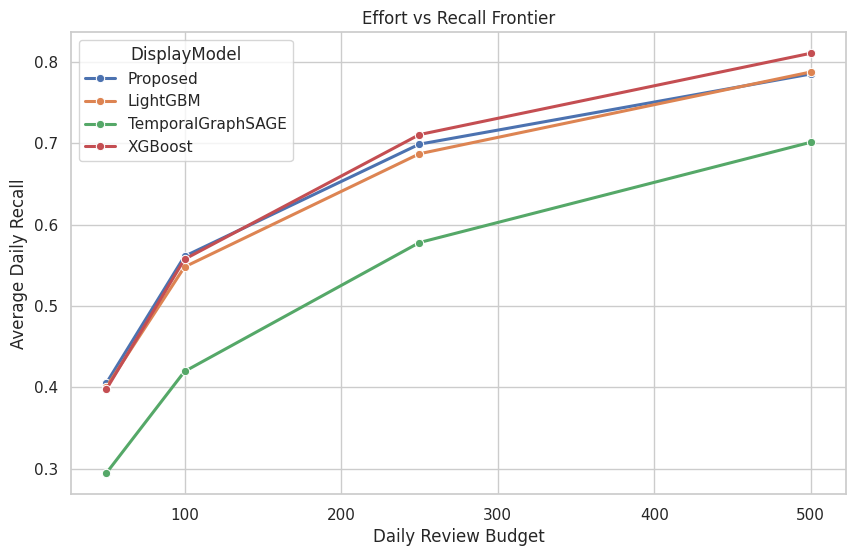

In [2]:
# Figure 6.1 - Effort vs Recall Frontier
frontier_order = ["LightGBM", "XGBoost", "TemporalGraphSAGE", "AttentionRanker"]
frontier_df = budget_df[budget_df["Model"].isin(frontier_order)].copy()
frontier_df["DisplayModel"] = frontier_df["Model"].replace({"AttentionRanker": "Proposed"})

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=frontier_df,
    x="Budget",
    y="AvgDailyRecall",
    hue="DisplayModel",
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Effort vs Recall Frontier")
ax.set_xlabel("Daily Review Budget")
ax.set_ylabel("Average Daily Recall")
save_figure(fig, "figure_6_1_effort_vs_recall_frontier")

In [3]:
# Table 6.1 - Budget-Constrained Performance
table_6_1 = (
    budget_df[budget_df["Model"].isin([baseline_model_name, proposal_model_name])]
    .pivot_table(index="Budget", columns="Model", values="AvgDailyRecall", aggfunc="first")
    .reset_index()
    .rename(columns={baseline_model_name: "XGBoost", proposal_model_name: "Proposed"})
)
table_6_1 = table_6_1[["Budget", "XGBoost", "Proposed"]].sort_values("Budget").reset_index(drop=True)
save_table(table_6_1, "table_6_1_budget_constrained_performance")

In [4]:
# Table 6.2 - ROI Analysis
# Use a fixed operating budget so the proposal-facing comparison is reproducible.
roi_reference_df = roi_df[
    (roi_df["Budget"] == reference_budget)
    & (roi_df["Model"].isin([baseline_model_name, proposal_model_name]))
].copy()

table_6_2 = roi_reference_df[["Model", "AvgNetBenefit"]].copy()
table_6_2["Method"] = table_6_2["Model"].map(
    {baseline_model_name: "Baseline", proposal_model_name: "Proposed"}
)
table_6_2["Estimated Savings"] = table_6_2["AvgNetBenefit"].map(lambda x: f"${x:,.2f}")
method_order = {"Baseline": 0, "Proposed": 1}
table_6_2["MethodOrder"] = table_6_2["Method"].map(method_order)
table_6_2 = (
    table_6_2.sort_values("MethodOrder")
    [["Method", "Estimated Savings"]]
    .reset_index(drop=True)
)
save_table(table_6_2, "table_6_2_roi_analysis")

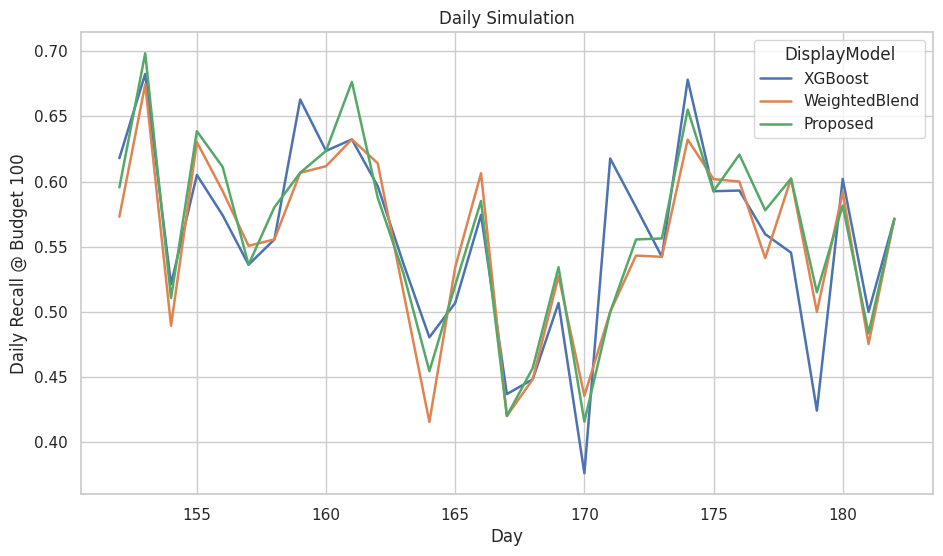

In [5]:
# Figure 6.2 - Daily Simulation
daily_reference_df = daily_sim_df[
    (daily_sim_df["Budget"] == reference_budget)
    & (daily_sim_df["Model"].isin([baseline_model_name, "WeightedBlend", proposal_model_name]))
].copy()
daily_reference_df["DisplayModel"] = daily_reference_df["Model"].replace(
    {"AttentionRanker": "Proposed"}
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=daily_reference_df,
    x="Day",
    y="DailyRecall",
    hue="DisplayModel",
    linewidth=1.8,
    ax=ax,
)
ax.set_title("Daily Simulation")
ax.set_xlabel("Day")
ax.set_ylabel(f"Daily Recall @ Budget {reference_budget}")
save_figure(fig, "figure_6_2_daily_simulation")